### **How the stimulus-generating functions work**

The synthetic signals above are produced by three helper functions in `neural_audio.utils.mathfuncs`. Each returns a 1-D waveform, which is then passed through `wav2aud` to produce the audiograms. Each is built based on known rate and/or scale parameters.

- **`gen_temporal_modulations_rate(rate)`: pure temporal modulation.** It places `round(rate * duration)` evenly spaced impulses along the time axis. An impulse contains all frequencies at once, so every frequency channel switches on and off together at the chosen `rate`. The audiogram therefore shows vertical bursts (temporal modulation) with no spectral structure.

- **`gen_spectral_modulations_scale(scale)`: pure spectral modulation.** It sums many log-spaced sinusoidal carriers with frequencies in the interval [`f_min`, `f_max`], which can be specified by the user. Each is weighted by a fixed amplitude $\sin(2\pi \cdot \text{scale} \cdot x)$, where $x$ is the carrier's position in octaves above `f_min`. This amplitude pattern repeats every $1/\text{scale}$ octaves, so the audiogram shows stationary horizontal stripes (spectral modulation) with no change over time. Each carrier is given a **random starting phase** so that neighbouring carriers do not beat coherently — without this, the coherent beating imprints a spurious, frequency-swept interference ("fingerprint") pattern on the audiogram.

- **`gen_ripple(rate, scale)`: a full spectrotemporal ripple.** It uses the same log-spaced carriers, but now each carrier's amplitude follows a *travelling* envelope $1 + A\,\sin(2\pi(\text{rate}\cdot t + \text{scale}\cdot x) + \Phi)$ that varies over both time and octave position. The result is a drifting diagonal ripple whose temporal speed is set by `rate` and whose spectral density is set by `scale`. This is the "broadband noise with sinusoidally modulated spectrotemporal envelope" of Chi et al. (2005). \[[1](#References)\]

These functions are useful for building intuition: feeding a signal with a known rate and scale into `aud2cor` makes it possible to confirm that energy appears in the expected rate and scale channels of the cortical representation.

In [ ]:
from neural_audio.utils.mathfuncs import gen_spectral_modulations_scale, gen_temporal_modulations_rate, gen_ripple
from neural_audio.wav2aud import wav2aud
from neural_audio.utils.visualize_outputs import plot_spectrogram
import numpy as np
import matplotlib.pyplot as plt

# NOTE - Lower resolution used (compared to default) to save memory and computation time
scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 16)
rates = 2 ** np.linspace(np.log2(0.5), np.log2(64), 16)


#### Effect of rate on a temporally-modulated signal
This is an example of a signal that contains no spectral changes - all frequencies are present, but only in short bursts, meaning only temporal modulations are present.

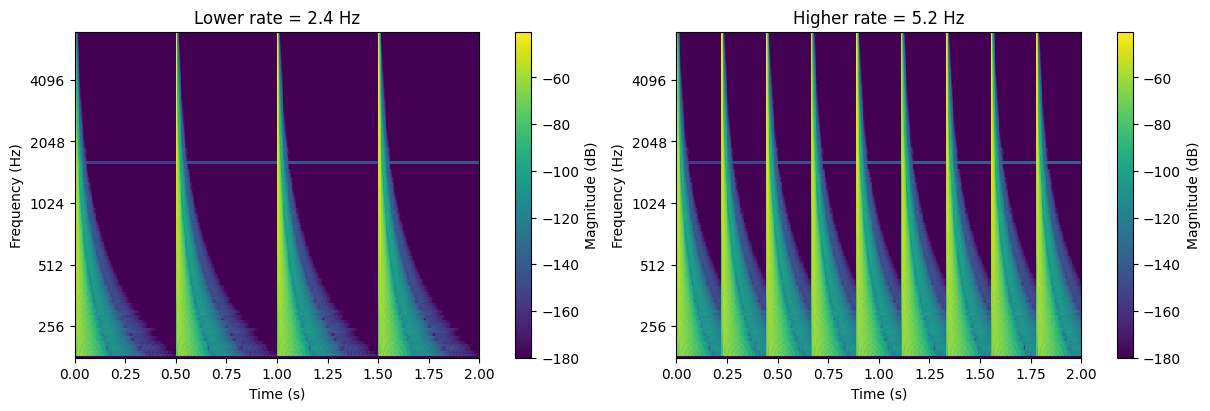

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

plt.sca(axes[0])
waveform = gen_temporal_modulations_rate(rates[10])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Lower rate = {rates[10]:.1f} Hz")

plt.sca(axes[1])
waveform = gen_temporal_modulations_rate(rates[15])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Higher rate = {rates[15]:.1f} Hz")

plt.show()

#### Effect of scale on a spectrally-modulated signal
Analogously to the above example, the signal below contains only spectral modulations. It is constant in time, but made up of various frequencies.

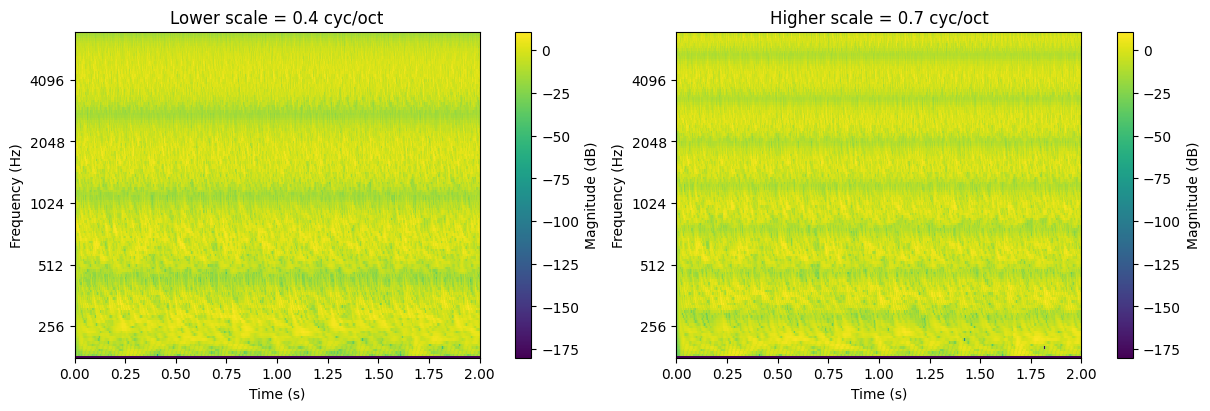

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

plt.sca(axes[0])
waveform = gen_spectral_modulations_scale(scales[5])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Lower scale = {scales[5]:.1f} cyc/oct")

plt.sca(axes[1])
waveform = gen_spectral_modulations_scale(scales[10])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Higher scale = {scales[10]:.1f} cyc/oct")

plt.show()

#### Effect of rate and scale on a ripple
Ripples are defined as "broadband noise with sinusoidally modulated spectrotemporal envelopes with different parameters"\[[1](#References)\]. In other words, this means the signal contains energy across a wide range of frequencies, but that energy is arranged in a sinusoidal pattern that varies across both time and frequency.

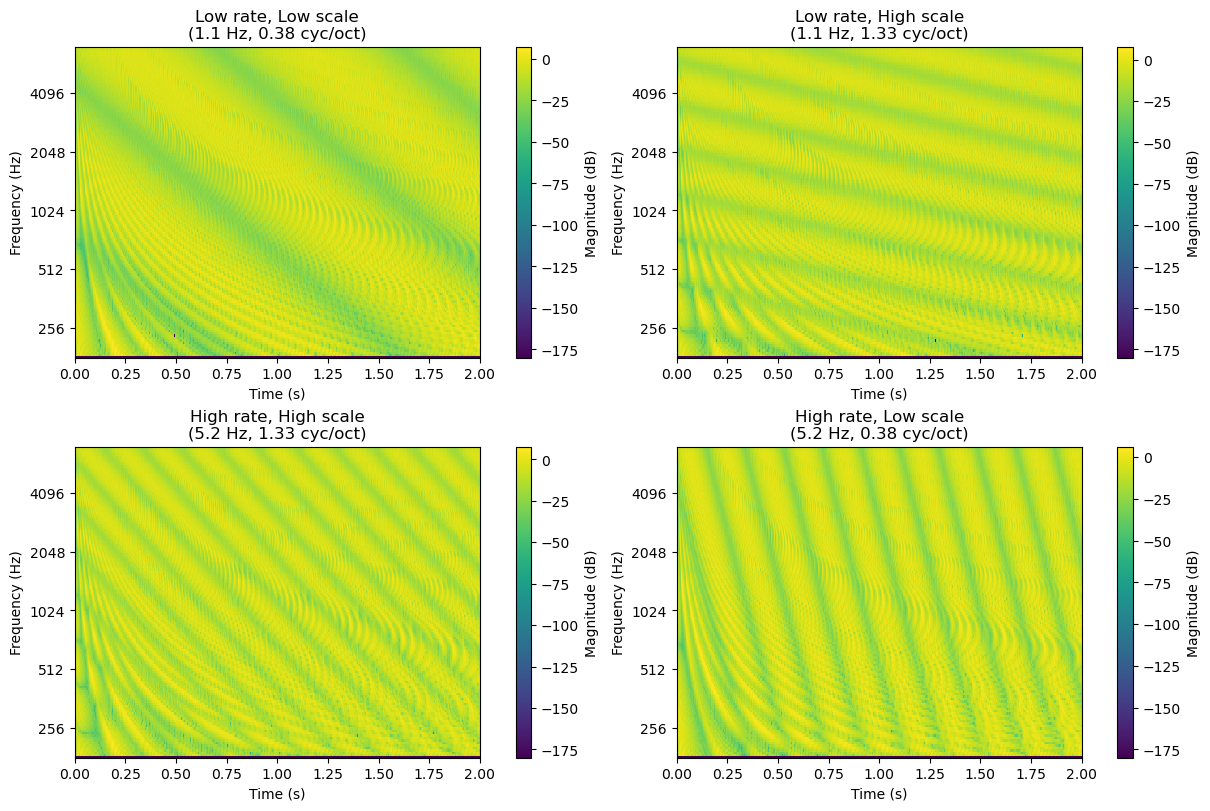

In [ ]:
# Low/high values to illustrate the effect
low_rate  = rates[5]
high_rate = rates[15]

low_scale  = scales[5]
high_scale = scales[15]

configs = [
    (low_rate,  low_scale,  "Low rate, Low scale"),
    (low_rate,  high_scale, "Low rate, High scale"),
    (high_rate, high_scale, "High rate, High scale"),
    (high_rate, low_scale,  "High rate, Low scale"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, (rate, scale, title) in zip(axes.flat, configs):

    waveform = gen_ripple(rate=rate, scale=scale)

    t, freqs, aud = wav2aud(waveform)

    plt.sca(ax)
    plot_spectrogram(
        aud,
        t,
        freqs,
        title=f"{title}\n({rate:.1f} Hz, {scale:.2f} cyc/oct)"
    )

plt.show()

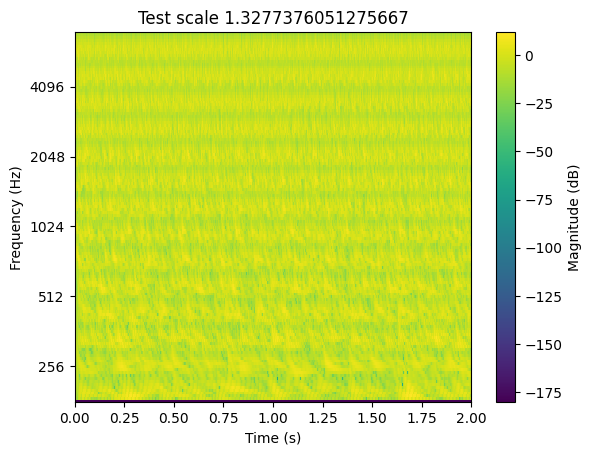

In [6]:
from neural_audio.utils.mathfuncs import gen_spectral_modulations_scale
test_wave = gen_spectral_modulations_scale(scale=scales[15])
tp, freqs, aud = wav2aud(test_wave)
plot_spectrogram(aud, tp, freqs, title=f"Test scale {scales[15]}")